* __Libraries/Modules import__

In [46]:
from pathlib import Path
import shutil
import sys

import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


from anpr.data.metadata import build_metadata_csv
from anpr.data.dataset import PlateDataset
from anpr.data.transforms import get_basic_transforms
from anpr.data.encoders import decode_indices
from anpr.models.plate_cnn import PlateCNN, count_trainable_parameters
from anpr.training.losses import PlateMultiHeadLoss
from anpr.inference.decode import decode_model_outputs
from anpr.evaluation.metrics import calculate_plate_metrics, format_plate_metrics
from anpr.inference.decode import decode_model_outputs
from anpr.training.train_loop import train_one_epoch, evaluate_one_epoch


### Dataset Inspection

* __Extracting raw data into correct folder structure__ 

In [ ]:

PROJECT_ROOT = Path("..").resolve()

SOURCE_ROOT = PROJECT_ROOT / "data" / "raw" / "UKLicencePlateDataset"
DEST_ROOT = PROJECT_ROOT / "data" / "raw" / "plate_crops"

SOURCE_FOLDERS = {
    "whiteplate_normal": "white",
    "yellowplate_normal": "yellow",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def copy_original_plate_images(source_root: Path, dest_root: Path) -> None:
    total_copied = 0

    for source_folder_name, dest_folder_name in SOURCE_FOLDERS.items():
        source_folder = source_root / source_folder_name
        dest_folder = dest_root / dest_folder_name

        if not source_folder.exists():
            raise FileNotFoundError(f"Missing source folder: {source_folder}")

        dest_folder.mkdir(parents=True, exist_ok=True)

        image_files = sorted(
            path for path in source_folder.rglob("*")
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        )

        print(f"{source_folder_name}: found {len(image_files)} images")

        for image_path in image_files:
            destination_path = dest_folder / image_path.name

            if destination_path.exists():
                raise FileExistsError(
                    f"Duplicate filename found: {destination_path.name}. "
                    "Keep subfolders or add a safe renaming strategy."
                )

            shutil.copy2(image_path, destination_path)
            total_copied += 1

    print(f"Done. Copied {total_copied} original images into: {dest_root}")

copy_original_plate_images(SOURCE_ROOT, DEST_ROOT)

whiteplate_normal: found 12000 images
yellowplate_normal: found 12000 images
Done. Copied 24000 original images into: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk-plate-recognition\data\raw\plate_crops


* __Making sure everything is loading correctly__ 

In [ ]:
DEST_ROOT = Path("../data/raw/plate_crops").resolve()

all_images = sorted(
    path for path in DEST_ROOT.rglob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
)

print("Total clean original images:", len(all_images))
print("First 10 images:")
for path in all_images[:10]:
    print(path.relative_to(DEST_ROOT))

Total clean original images: 24000
First 10 images:
white\AA03BOJ.png
white\AA06OHE.png
white\AA15VJJ.png
white\AA19HSV.png
white\AA22JTE.png
white\AA25WEI.png
white\AA39HMS.png
white\AA61PSS.png
white\AA67AAL.png
white\AA70PYY.png


* __Metadata building__ 

In [18]:
PROJECT_ROOT = Path("..").resolve()

df = build_metadata_csv(
    image_dir=PROJECT_ROOT / "data" / "raw" / "plate_crops",
    output_csv=PROJECT_ROOT / "data" / "metadata" / "plates.csv",
    invalid_csv=PROJECT_ROOT / "data" / "metadata" / "invalid_plates.csv",
    project_root=PROJECT_ROOT,
    source_name="uk_plate_original_crops",
    allow_embedded_plate=False,
    random_state=42,
)

df.head()

,image_id,image_path,label,label_length,source,split
0,AA03BOJ,data/raw/plate_crops/white/AA03BOJ.png,AA03BOJ,7,uk_plate_original_crops,train
1,AA06OHE,data/raw/plate_crops/white/AA06OHE.png,AA06OHE,7,uk_plate_original_crops,train
2,AA15VJJ,data/raw/plate_crops/white/AA15VJJ.png,AA15VJJ,7,uk_plate_original_crops,train
3,AA19HSV,data/raw/plate_crops/white/AA19HSV.png,AA19HSV,7,uk_plate_original_crops,train
4,AA22JTE,data/raw/plate_crops/white/AA22JTE.png,AA22JTE,7,uk_plate_original_crops,train


* __Inspecting metadata built__

In [19]:
df.shape

(24000, 6)

In [20]:
df.head()

,image_id,image_path,label,label_length,source,split
0,AA03BOJ,data/raw/plate_crops/white/AA03BOJ.png,AA03BOJ,7,uk_plate_original_crops,train
1,AA06OHE,data/raw/plate_crops/white/AA06OHE.png,AA06OHE,7,uk_plate_original_crops,train
2,AA15VJJ,data/raw/plate_crops/white/AA15VJJ.png,AA15VJJ,7,uk_plate_original_crops,train
3,AA19HSV,data/raw/plate_crops/white/AA19HSV.png,AA19HSV,7,uk_plate_original_crops,train
4,AA22JTE,data/raw/plate_crops/white/AA22JTE.png,AA22JTE,7,uk_plate_original_crops,train


In [21]:
df["split"].value_counts()

split
train    19200
test      2400
val       2400
Name: count, dtype: int64

In [22]:
df["label"].str.len().value_counts()

label
7    24000
Name: count, dtype: int64

* __Data Split + Transfomation__

In [24]:
PROJECT_ROOT = Path("..").resolve()
METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates.csv"

transform = get_basic_transforms(
    image_height=48,
    image_width=160,
)

train_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="train",
    transform=transform,
    grayscale=True,
)

val_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="val",
    transform=transform,
    grayscale=True,
)

test_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="test",
    transform=transform,
    grayscale=True,
)

len(train_ds), len(val_ds), len(test_ds)

(19200, 2400, 2400)

* __Inspecting the results__

In [25]:
sample = train_ds[0]

print("Image shape:", sample["image"].shape)
print("Target shape:", sample["target"].shape)
print("Target:", sample["target"])
print("Label:", sample["label"])
print("Image path:", sample["image_path"])

Image shape: torch.Size([1, 48, 160])
Target shape: torch.Size([7])
Target: tensor([ 0,  0,  0,  3,  1, 14,  9])
Label: AA03BOJ
Image path: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA03BOJ.png


* __Testing DataLoader__

In [26]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

batch = next(iter(train_loader))

print("Batch image shape:", batch["image"].shape)
print("Batch target shape:", batch["target"].shape)
print("First labels:", batch["label"][:5])

Batch image shape: torch.Size([32, 1, 48, 160])
Batch target shape: torch.Size([32, 7])
First labels: ['JP29JML', 'UE51HSI', 'AV37LZM', 'VT29LFV', 'RL12QBO']


In [43]:
val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

batch = next(iter(val_loader))

print("Batch image shape:", batch["image"].shape)
print("Batch target shape:", batch["target"].shape)
print("First labels:", batch["label"][:5])

Batch image shape: torch.Size([32, 1, 48, 160])
Batch target shape: torch.Size([32, 7])
First labels: ['CE69UPI', 'AS98JTA', 'FT84WFK', 'AG94UXP', 'VF84QON']


In [44]:
test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

batch = next(iter(test_loader))

print("Batch image shape:", batch["image"].shape)
print("Batch target shape:", batch["target"].shape)
print("First labels:", batch["label"][:5])

Batch image shape: torch.Size([32, 1, 48, 160])
Batch target shape: torch.Size([32, 7])
First labels: ['FB66ZBU', 'QA75LYH', 'LX87SCX', 'GP47LBS', 'CV03IVQ']


* __Visual sanity check of loaded plate tensors__

In [28]:
sample = train_ds[0]

image = sample["image"]
target = sample["target"]
label = sample["label"]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Image min:", image.min().item())
print("Image max:", image.max().item())
print("Image mean:", image.mean().item())

print("Target:", target.tolist())
print("Decoded target:", decode_indices(target.tolist()))
print("Original label:", label)

assert image.shape == (1, 48, 160)
assert target.shape == (7,)
assert decode_indices(target.tolist()) == label

Image shape: torch.Size([1, 48, 160])
Image dtype: torch.float32
Image min: -1.0
Image max: 0.9843137860298157
Image mean: 0.2363511472940445
Target: [0, 0, 0, 3, 1, 14, 9]
Decoded target: AA03BOJ
Original label: AA03BOJ


* __Displaying the image__

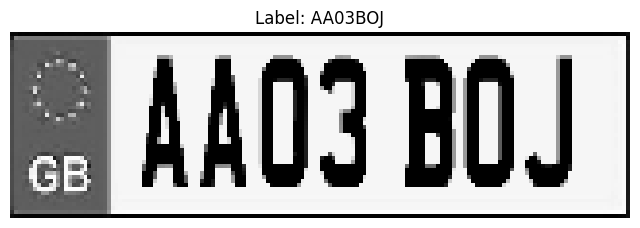

In [30]:
def denormalise_plate_tensor(image_tensor):
    """
    Convert Tensor[1, H, W] from roughly [-1, 1] back to [0, 1]
    for display only.
    """
    image = image_tensor.squeeze(0).detach().cpu().numpy()
    image = (image * 0.5) + 0.5
    image = image.clip(0, 1)
    return image


sample = train_ds[0]

plt.figure(figsize=(8, 3))
plt.imshow(denormalise_plate_tensor(sample["image"]), cmap="gray")
plt.title(f"Label: {sample['label']}")
plt.axis("off")
plt.show()

* __Displaying a bactch of images__

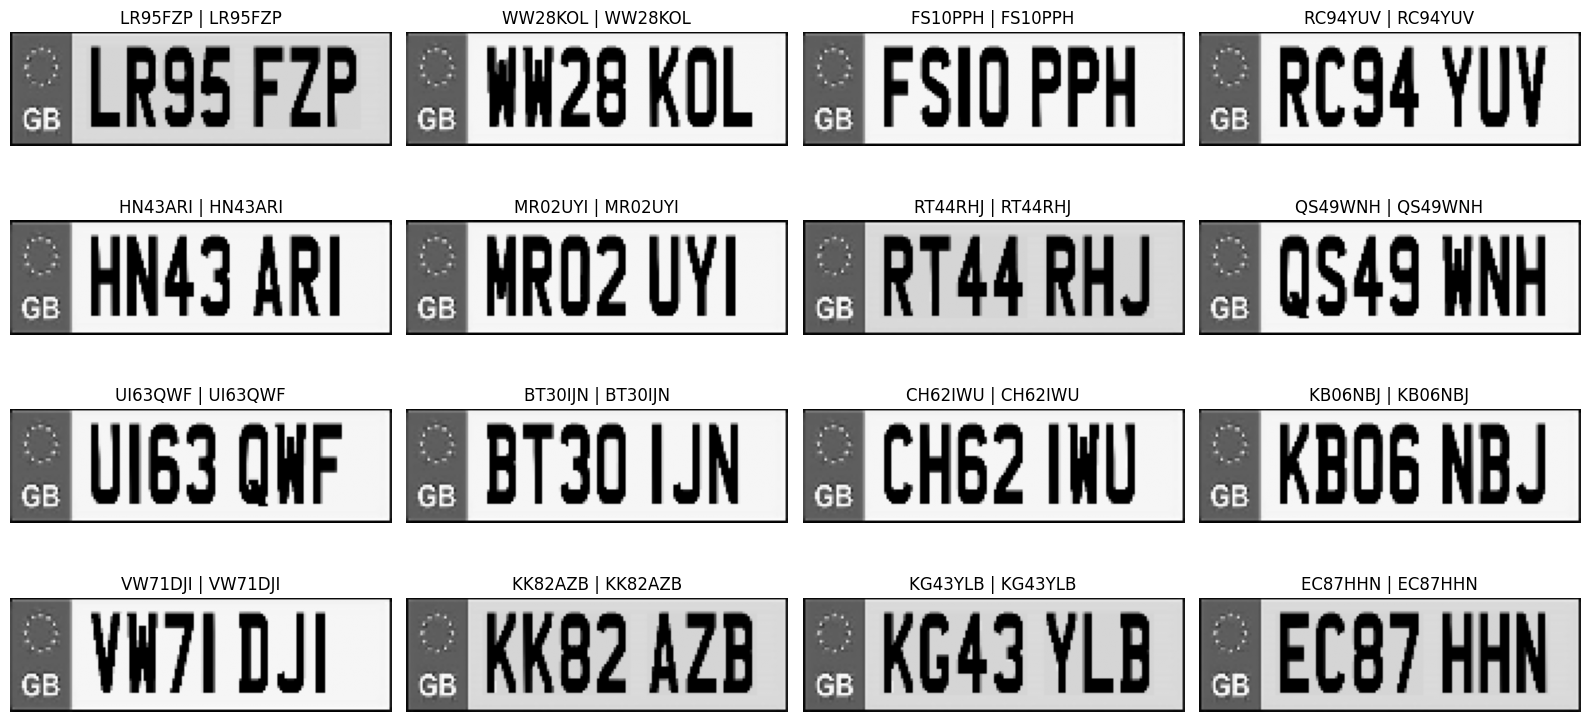

In [31]:
batch = next(iter(train_loader))

images = batch["image"]
targets = batch["target"]
labels = batch["label"]

num_images = 16

plt.figure(figsize=(16, 8))

for i in range(num_images):
    plt.subplot(4, 4, i + 1)

    image = denormalise_plate_tensor(images[i])
    decoded = decode_indices(targets[i].tolist())

    plt.imshow(image, cmap="gray")
    plt.title(f"{labels[i]} | {decoded}")
    plt.axis("off")

plt.tight_layout()
plt.show()

* __DataLoader sanity check__

In [32]:
batch = next(iter(train_loader))

assert batch["image"].ndim == 4
assert batch["target"].ndim == 2

assert batch["image"].shape[1:] == (1, 48, 160)
assert batch["target"].shape[1] == 7

print("Batch image shape:", batch["image"].shape)
print("Batch target shape:", batch["target"].shape)
print("Image value range:", batch["image"].min().item(), batch["image"].max().item())
print("First 5 labels:", batch["label"][:5])

Batch image shape: torch.Size([32, 1, 48, 160])
Batch target shape: torch.Size([32, 7])
Image value range: -1.0 0.9843137860298157
First 5 labels: ['PJ68OUE', 'NX97DFI', 'SO23ACF', 'AJ87NNY', 'WU19JMY']


### Baseline CNN Testing

* __Loading CNN__

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PlateCNN(in_channels=1).to(device)

print(model)
print("Trainable parameters:", count_trainable_parameters(model))

PlateCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

* __Testing on Batches__ 

In [35]:
batch = next(iter(train_loader))

images = batch["image"].to(device)
targets = batch["target"].to(device)

outputs = model(images)

print("Number of heads:", len(outputs))

for position, output in enumerate(outputs):
    print(f"Position {position}: output shape = {output.shape}")

print("Target shape:", targets.shape)

Number of heads: 7
Position 0: output shape = torch.Size([32, 26])
Position 1: output shape = torch.Size([32, 26])
Position 2: output shape = torch.Size([32, 10])
Position 3: output shape = torch.Size([32, 10])
Position 4: output shape = torch.Size([32, 26])
Position 5: output shape = torch.Size([32, 26])
Position 6: output shape = torch.Size([32, 26])
Target shape: torch.Size([32, 7])


* __Model & Loss Testing__

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PlateCNN(in_channels=1).to(device)
loss_fn = PlateMultiHeadLoss()

batch = next(iter(train_loader))

images = batch["image"].to(device)
targets = batch["target"].to(device)

outputs = model(images)

total_loss, position_losses = loss_fn(outputs, targets)

print("Total loss:", total_loss.item())

for position, position_loss in enumerate(position_losses):
    print(f"Position {position} loss:", position_loss.item())

Total loss: 3.021352529525757
Position 0 loss: 3.3154470920562744
Position 1 loss: 3.3065195083618164
Position 2 loss: 2.2885923385620117
Position 3 loss: 2.3114349842071533
Position 4 loss: 3.2759766578674316
Position 5 loss: 3.268982410430908
Position 6 loss: 3.3825137615203857


* __Testing Prediction Format__

In [39]:
model.eval()

batch = next(iter(train_loader))

images = batch["image"].to(device)
labels = batch["label"]

with torch.no_grad():
    outputs = model(images)

predictions = decode_model_outputs(outputs)

for i in range(10):
    print(
        "True:",
        labels[i],
        "| Pred:",
        predictions[i].cleaned_prediction,
        "| Valid:",
        predictions[i].is_valid_format,
        "| Confidence:",
        round(predictions[i].overall_confidence, 4),
    )

True: XS32CAW | Pred: PP97VIP | Valid: True | Confidence: 0.0607
True: DI05ONU | Pred: PP97VIP | Valid: True | Confidence: 0.0608
True: PI49IXT | Pred: PP97YIP | Valid: True | Confidence: 0.0607
True: GG45VOR | Pred: PP97VIP | Valid: True | Confidence: 0.0608
True: UO72FGM | Pred: PP97VPP | Valid: True | Confidence: 0.0609
True: ZM42DWD | Pred: PP97VPP | Valid: True | Confidence: 0.0609
True: LL30ZJQ | Pred: PP97YIP | Valid: True | Confidence: 0.0607
True: LZ82YKN | Pred: PP97VIP | Valid: True | Confidence: 0.0607
True: BG70PBA | Pred: PP97VIP | Valid: True | Confidence: 0.0607
True: FD68GKL | Pred: PP97VPP | Valid: True | Confidence: 0.0609


* __Metrics Check__

In [45]:
model.eval()

batch = next(iter(val_loader))

images = batch["image"].to(device)
labels = list(batch["label"])

with torch.no_grad():
    outputs = model(images)

predictions = decode_model_outputs(outputs)

metrics = calculate_plate_metrics(predictions, labels)

print(format_plate_metrics(metrics))

Samples: 32
Full-plate accuracy: 0.0000
Regex-valid rate: 1.0000
Average confidence: 0.0608
Per-position accuracy:
  Position 0: 0.0312
  Position 1: 0.0000
  Position 2: 0.1250
  Position 3: 0.0938
  Position 4: 0.0625
  Position 5: 0.0625
  Position 6: 0.0000


* __Test Training Loop__

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PlateCNN(in_channels=1).to(device)
loss_fn = PlateMultiHeadLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [48]:
train_result = train_one_epoch(
    model=model,
    dataloader=train_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    max_batches=5,
)

val_result = evaluate_one_epoch(
    model=model,
    dataloader=val_loader,
    loss_fn=loss_fn,
    device=device,
    max_batches=5,
)

print("Train loss:", train_result.loss)
print("Train position losses:", train_result.position_losses)

print("Val loss:", val_result.loss)
print("Val position losses:", val_result.position_losses)

print(format_plate_metrics(val_result.metrics))

Train loss: 3.013805961608887
Train position losses: [3.302172136306763, 3.2809331893920897, 2.321978282928467, 2.352579879760742, 3.266934394836426, 3.3068357944488525, 3.265207815170288]
Val loss: 2.9899219036102296
Val position losses: [3.254864549636841, 3.2595044136047364, 2.3106804847717286, 2.3032485485076903, 3.2694334030151366, 3.2682526111602783, 3.263469696044922]
Samples: 160
Full-plate accuracy: 0.0000
Regex-valid rate: 1.0000
Average confidence: 0.0640
Per-position accuracy:
  Position 0: 0.0375
  Position 1: 0.0437
  Position 2: 0.0938
  Position 3: 0.0875
  Position 4: 0.0187
  Position 5: 0.0437
  Position 6: 0.0312
